# Normalizando y limpiando contenido de archivos markdown

Luego de hacer scraping sitios como lexivox incluyen secciones de suscripción y enlaces a las normas que hacen referencia a este mismo sitio. Se va a limpiar estos para tener un contenido en markdown limpio.

## Lexivox Quitando secciones de suscripción y enlaces que hacen referencia al mismo sitio

Por ejemplo
```md
[*Aumentar el tamaño del texto*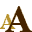](#normText)[*Reducir el tamaño del texto*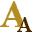]

...

* Que, mediante [Decreto Supremo Nº 10559](https://www.lexivox.org//norms/BO-DS-10559.html) de 8 noviembre de, 1972, 
```

In [57]:
import re

NORMAS_FOLDER = '../../normas/raw'

def limpiar_enlaces_estandar(texto_linea):
    """
    Función simple que convierte enlaces normales [Texto](URL) a solo 'Texto'.
    Solo se ejecuta en líneas que tú consideres seguras.
    """
    # Regex sencillo para enlaces que no contienen imágenes anidadas
    pattern = r'\[([^\]]+)\]\([^\)]+\)'
    # Reemplaza el enlace original por el texto con la etiqueta TODO
    return re.sub(pattern, r'[\1](#TODO-link)', texto_linea)

def procesar_documento(input_file):
    lineas_limpias = []
    
    with open(input_file, "r", encoding="utf-8") as f:
        for num_linea, linea in enumerate(f, start=1):
            
            # --- DETECCIÓN MANUAL DE LÍNEAS RARAS ---
            # Caso 1: Detectar las barras de navegación con imágenes Base64 gigantes
            if linea.startswith('[*'):
                # Opción A: Borrar la línea por completo (elimina la barra de herramientas)
                continue 

            # Caso 2: Ignorar o tratar de forma especial líneas vacías o bloques de código
            elif linea.strip() == "":
                lineas_limpias.append(linea)
                continue

            # Caso 3: Línea normal segura. Aplicamos la limpieza de Markdown
            else:
                linea_procesada = limpiar_enlaces_estandar(linea)
                lineas_limpias.append(linea_procesada)
        return ''.join(lineas_limpias)

print('-------------------')
contenido_limpio = procesar_documento(f"{NORMAS_FOLDER}/1880/ley---18800601.md")
print(contenido_limpio)
                
    # Guardar el resultado en el nuevo archivo
    # with open(output_file, "w", encoding="utf-8") as f:
    #     f.writelines(lineas_limpias)

-------------------


# Bolivia: Ley de 1 de junio de 1880

LA CONVENCION NACIONAL
  
Decreta:

**Artículo 1°.-** En recompensa de los importantes servicios prestados a la nacion se asciende al alto grado de jeneral de brigada al coronel don Eliodoro Camacho.

**Artículo 2°.-** Se confiere una medalla de honor y el título de benemérito a la patria, al ciudadano Ladislao Cabrera, por la heróica defensa de Calama y sus relevantes servicios a la patria.

**Artículo 3°.-** Se confiere igualmente una medalla de honor al ciudadano Belisario Salínas, por su comportamiento patriótico.

---

Comuníquese al poder ejecutivo para su ejecucion y cumplimiento.
  
Sala de sesiones.-
  
La Paz, mayo 31 de 1880.
  
Rudesindo Carvajal.- Belisario Boeto, diputado secretario.- Demetrio Calbimonte, diputado secretario.
  
Casa de gobierno.- La Paz, a 1 de junio de 1880.
  
Ejecútese.- Aniceto Arce.- Jenaro Sanjinés.- Andrés Soto.


In [58]:
contenido_limpio = procesar_documento(f"{NORMAS_FOLDER}/1973/decreto-ley---10135.md")
print(contenido_limpio)

# Bolivia: Decreto Ley Nº 10135, 16 de febrero de 1973

"CODIGO DEL TRÁNSITO"
  
[Decreto Ley Nº 10135](#TODO-link) 16 DE FEBRERO DE 1973
  
Gral. HUGO BANZER SUAREZ Presidente de la República

CONSIDERANDO:

* Que, mediante [Decreto Supremo Nº 10559](#TODO-link) de 8 noviembre de, 1972, se ha constituido la Comisión Redactora del proyecto del Código Nacional de Tránsito. Que, el proyecto presentado por la citada Comisión, contiene importantes normas que regulan la circulación de los peatones y vehículos entre las que destaca la ley de la calzada.
* Que es deber del Gobierno Nacionalista dotar al país, en materia de Tránsito de un instrumento legal acorde con las actuales necesidades y el crecimiento experimentado por el autotransporte Nacional.

En Consejo de Ministros, Decreta:

**Artículo 1°.-** Apruébase él Código Nacional del Tránsito en sus VII Títulos y 200 Artículos, el mismo que entrará en vigencia, en todo el territorio nacional, a partir del día 2 de abril de 1973.

**Artícu

## Iterando y escribiendo cambios en los documentos markdown

In [59]:
import os 

NORMAS_FOLDER = '../../normas/raw'
OUTPUT_FOLDER = '../../normas/normalized'

def procesar_todas_las_carpetas(directorio_base):
    """
    Recorre las carpetas del directorio base buscando archivos .md
    """
    # Creamos una carpeta de salida independiente para proteger tus archivos originales
    
    # os.walk recorre carpetas y subcarpetas automáticamente
    count = 0
    for raiz, dectector_carpetas, archivos in os.walk(directorio_base):
        
        # # Saltamos la carpeta de salida si el script se vuelve a ejecutar en el mismo sitio
        # if NORMAS_FOLDER in raiz:
        #     continue
        for archivo in archivos:
            if archivo.endswith(".md"):
                # Ruta completa del archivo original (ej: 1888/ley---5141.md)
                ruta_completa_origen = os.path.join(raiz, archivo)
                
                # Replicamos la estructura de carpetas en el destino (ej: resultado_limpio/1888/)
                ruta_relativa = os.path.relpath(raiz, directorio_base)
                carpeta_destino_final = os.path.join(OUTPUT_FOLDER, ruta_relativa)
                os.makedirs(carpeta_destino_final, exist_ok=True)
                
                ruta_completa_destino = os.path.join(carpeta_destino_final, archivo)
                
                # Procesamos el archivo específico
                contenido_limpio = procesar_documento(ruta_completa_origen)

                # Escribe el resultado en la ruta de destino
                with open(ruta_completa_destino, "w", encoding="utf-8") as f:
                    f.write(contenido_limpio)
                count += 1

                if count%500 == 0:
                    print(f'procesados {count}')
                #print(f"Procesado con éxito: {ruta_completa_origen} -> {ruta_completa_destino}")


procesar_todas_las_carpetas(NORMAS_FOLDER)
print('finalizado')

procesados 500
procesados 1000
procesados 1500
procesados 2000
procesados 2500
procesados 3000
procesados 3500
procesados 4000
procesados 4500
procesados 5000
procesados 5500
procesados 6000
procesados 6500
procesados 7000
procesados 7500
procesados 8000
procesados 8500
procesados 9000
procesados 9500
procesados 10000
procesados 10500
procesados 11000
procesados 11500
procesados 12000
procesados 12500
procesados 13000
procesados 13500
procesados 14000
procesados 14500
procesados 15000
procesados 15500
procesados 16000
procesados 16500
procesados 17000
procesados 17500
procesados 18000
procesados 18500
procesados 19000
procesados 19500
procesados 20000
procesados 20500
procesados 21000
procesados 21500
procesados 22000
procesados 22500
procesados 23000
procesados 23500
procesados 24000
procesados 24500
procesados 25000
procesados 25500
procesados 26000
procesados 26500
procesados 27000
finalizado
